In [1]:
#RNN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.__version__

'2.21.0'

In [2]:
df = pd.read_csv("IMDB Dataset.csv")
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df['sentiment'] = df['sentiment'].map({'positive': 1,'negative': 0})

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [5]:
x = df['review']
y = df['sentiment']

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(x)

x_seq = tokenizer.texts_to_sequences(x)

In [7]:
max_length = 200

In [8]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
x_pad = pad_sequences(x_seq, max_length)

In [9]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x_pad, y, test_size=0.2, random_state=4)

In [14]:
x = layers.Input(shape=(max_length,))
embedding = layers.Embedding(input_dim=10000, output_dim=128)(x)

rnn = layers.SimpleRNN(128, activation='tanh', return_sequences=True)(embedding)
rnn = layers.SimpleRNN(64, activation='tanh')(rnn)

dense = layers.Dense(64, activation='relu')(rnn)
dense = layers.Dropout(0.3)(dense)

output = layers.Dense(1, activation='sigmoid')(dense)

model = keras.Model(inputs=x, outputs=output)

In [15]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_2 (SimpleRNN)             │ (None, 200, 128)            │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn_3 (SimpleRNN)             │ (None, 64)                  │          12,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,329,473 (5.07 MB)

 Trainable params: 1,329,473 (5.07 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(x_train, y_train, epochs=20, verbose=2, validation_data=(x_test, y_test))

Epoch 1/20
1250/1250 - 165s - 132ms/step - accuracy: 0.5009 - loss: 0.6989 - val_accuracy: 0.5041 - val_loss: 0.6932
Epoch 2/20
1250/1250 - 156s - 125ms/step - accuracy: 0.5011 - loss: 0.6939 - val_accuracy: 0.5041 - val_loss: 0.6960
Epoch 3/20
1250/1250 - 87s - 70ms/step - accuracy: 0.4980 - loss: 0.6939 - val_accuracy: 0.5041 - val_loss: 0.6931
Epoch 4/20
1250/1250 - 90s - 72ms/step - accuracy: 0.4979 - loss: 0.6939 - val_accuracy: 0.5042 - val_loss: 0.6931
Epoch 5/20
1250/1250 - 105s - 84ms/step - accuracy: 0.4993 - loss: 0.6940 - val_accuracy: 0.5041 - val_loss: 0.6931
Epoch 6/20
1250/1250 - 206s - 165ms/step - accuracy: 0.5253 - loss: 0.6875 - val_accuracy: 0.5785 - val_loss: 0.6778
Epoch 7/20
1250/1250 - 188s - 150ms/step - accuracy: 0.6367 - loss: 0.6290 - val_accuracy: 0.7022 - val_loss: 0.5708
Epoch 8/20
1250/1250 - 205s - 164ms/step - accuracy: 0.7434 - loss: 0.5289 - val_accuracy: 0.7561 - val_loss: 0.5127
Epoch 9/20
1250/1250 - 198s - 159ms/step - accuracy: 0.7792 - loss: 0

In [17]:
def plot_results(history):
    results = pd.DataFrame({"Train Loss": history.history['loss'], "Validation Loss": history.history['val_loss'],
              "Train Accuracy": history.history['accuracy'], "Validation Accuracy": history.history['val_accuracy']
             })
    fig, ax = plt.subplots(nrows=2, figsize=(16, 9))
    results[["Train Loss", "Validation Loss"]].plot(ax=ax[0])
    results[["Train Accuracy", "Validation Accuracy"]].plot(ax=ax[1])
    ax[0].set_xlabel("Epoch")
    ax[1].set_xlabel("Epoch")
    plt.show()

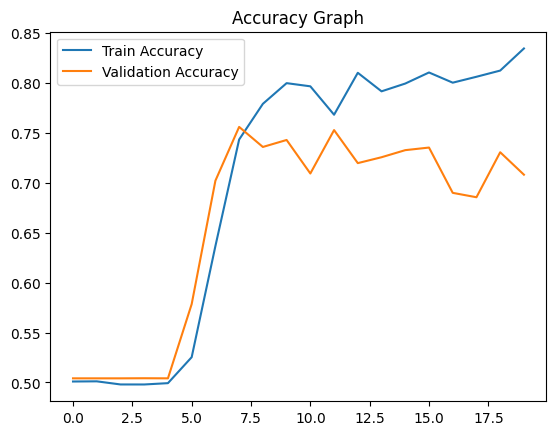

In [18]:
#acc visualization
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

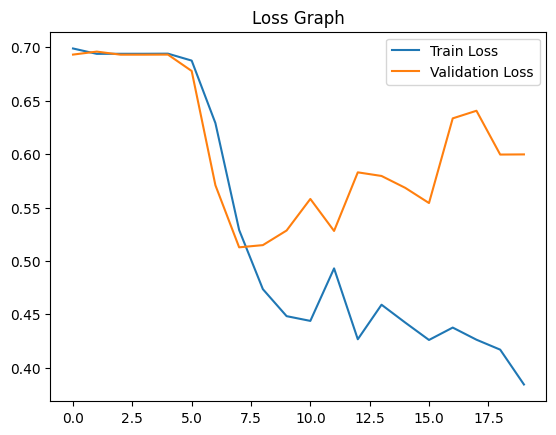

In [19]:
#loss visualization
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()